# 1.Contextualização


Este trabalho foi desenvolvido pela aluna Evelyn Klein (Turma 2026/1 - V2) como Projeto Final da Unidade Curricular "Modelagem de Dados" do programa SCTEC/SENAI para fins de avaliação e conclusão do Módulo 1 do Curso "Visualização de Dados e Business Intelligence".

Inicialmente, os dados foram consultados em um banco de dados SQL por meio de duas queries, responsáveis por extrair informações sobre funcionários, salários, departamentos e localização geográfica.

Em seguida, os dados passaram por etapas de exploração, análise estatística e visualização gráfica para identificação de padrões e geração de insights apresentadas neste notebook.

# 2.Objetivos



O principal objetivo deste projeto foi realizar uma Análise Exploratória de Dados (EDA) utilizando informações de funcionários de uma empresa. Para isso, buscou-se:

- extrair dados de um banco SQL utilizando consultas (queries);
- importar e manipular os dados no Python;
- realizar análises estatísticas descritivas;
- identificar padrões na distribuição dos salários;
- comparar a remuneração entre departamentos e regiões;
- identificar possíveis valores atípicos (outliers);
- apresentar os resultados por meio de gráficos e tabelas.

# 3.Metodologia


## 3.1 Banco de Dados e Consultas SQL





Foram utilizadas duas consultas SQL sobre a base de dados de Recursos Humanos (HR).

### 3.1.1 Query 1




A primeira consulta retornou informações sobre funcionários, incluindo identificação, cargo, departamento e salário.

Foram selecionadas as colunas EMPLOYEE_ID, FIRST_NAME, LAST_NAME, SALARY, JOB_TITLE e DEPARTMENT_NAME, permitindo analisar a distribuição salarial entre cargos e departamentos.

### 3.1.2 Query 2




A segunda consulta reuniu dados de localização, como cidade, país e região.

Foram selecionadas as colunas EMPLOYEE_ID, FIRST_NAME, LAST_NAME, DEPARTMENT_NAME, CITY, COUNTRY_NAME e REGION_NAME, possibilitando análises comparativas entre diferentes regiões geográficas.

Ambas as queries foram construídas com LEFT JOIN, preservando os registros da tabela principal e permitindo relacionar os campos das tabelas auxiliares mesmo quando alguma informação não estivesse disponível.

As duas bases foram posteriormente integradas pela coluna EMPLOYEE_ID, o que possibilitou cruzar as informações salariais com os dados de localização.

Após a integração, a base resultante manteve 107 registros da Query 1. Como a Query 2 possui 106 linhas, um colaborador não apresentou correspondência geográfica; por isso, as análises por região consideram apenas os 106 registros com localização preenchida.

Após a execução das consultas, os resultados foram exportados para arquivos CSV e enviados ao repositório do GitHub do projeto.

O código SQL completo das consultas encontra-se disponível no Apêndice A deste trabalho e também na pasta `sql` do repositório.

## 3.2 Importação das Bibliotecas

Nesta etapa são importadas as bibliotecas necessárias para a análise dos dados.

O Pandas será utilizado para leitura e manipulação dos arquivos CSV, enquanto o Matplotlib será utilizado para a criação dos gráficos.


In [1]:
from pathlib import Path

try:
    PROJECT_DIR = Path(__file__).resolve().parent.parent
except NameError:
    BASE_DIR = Path.cwd()
    if (BASE_DIR / "data").exists():
        PROJECT_DIR = BASE_DIR
    elif (BASE_DIR.parent / "data").exists():
        PROJECT_DIR = BASE_DIR.parent
    else:
        PROJECT_DIR = BASE_DIR

DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs" / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib
RUNNING_AS_SCRIPT = "__file__" in globals()
if RUNNING_AS_SCRIPT:
    matplotlib.use("Agg")

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
# Formata valores numéricos com duas casas decimais no pandas.
pd.set_option("display.float_format", "{:,.2f}".format)


def format_currency(value):
    return f"R$ {value:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

## 3.3 Carregamento dos CSVs

Nesta etapa são carregados os arquivos CSV gerados a partir das consultas SQL realizadas no banco de dados FreeSQL.

Os dados serão armazenados em DataFrames para permitir a análise exploratória.


In [2]:
df1 = pd.read_csv(DATA_DIR / "query_01.csv")
df2 = pd.read_csv(DATA_DIR / "query_02.csv")

# 4.Análise Exploratória de Dados (EDA)


A presente Análise Exploratória de Dados (EDA) buscou compreender a estrutura da base, identificar possíveis inconsistências, calcular estatísticas descritivas e gerar visualizações que auxiliem na identificação de padrões de remuneração, diferenças entre grupos e possíveis valores atípicos.

## 4.1 Verificação inicial dos dados
Nesta etapa foi realizada uma inspeção inicial dos dados para verificar se os arquivos CSV foram carregados corretamente.

Foram utilizadas as funções head(), info(), describe() e isnull().sum() para conhecer a estrutura dos dados, os tipos das variáveis, as estatísticas descritivas e a existência de valores ausentes.


In [3]:
df1.head()

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,SALARY,JOB_TITLE,DEPARTMENT_NAME
0,100,Steven,King,24000,President,Executive
1,101,Neena,Yang,17000,Administration Vice President,Executive
2,102,Lex,Garcia,17000,Administration Vice President,Executive
3,145,John,Singh,14000,Sales Manager,Sales
4,146,Karen,Partners,13500,Sales Manager,Sales


A visualização das primeiras linhas do conjunto de dados confirma que a Query 1 foi importada corretamente.

O conjunto contém informações de identificação dos funcionários, salário, cargo e departamento, que serão utilizadas nas análises estatísticas realizadas ao longo do estudo.

In [4]:
df2.head()

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,DEPARTMENT_NAME,CITY,COUNTRY_NAME,REGION_NAME
0,202,Pat,Davis,Marketing,Toronto,Canada,Americas
1,201,Michael,Martinez,Marketing,Toronto,Canada,Americas
2,206,William,Gietz,Accounting,Seattle,United States of America,Americas
3,205,Shelley,Higgins,Accounting,Seattle,United States of America,Americas
4,113,Luis,Popp,Finance,Seattle,United States of America,Americas


A visualização das primeiras linhas da Query 2 confirma que os dados também foram importados corretamente.

O segundo conjunto reúne informações sobre departamentos, cidades, países e regiões dos colaboradores, possibilitando análises relacionadas à distribuição geográfica dos funcionários.

## 4.2 Estrutura e Qualidade dos Dados
A função info() foi utilizada para verificar o tipo de cada coluna e a quantidade de registros presentes nos conjuntos de dados.


In [5]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   EMPLOYEE_ID      107 non-null    int64
 1   FIRST_NAME       107 non-null    str  
 2   LAST_NAME        107 non-null    str  
 3   SALARY           107 non-null    int64
 4   JOB_TITLE        107 non-null    str  
 5   DEPARTMENT_NAME  106 non-null    str  
dtypes: int64(2), str(4)
memory usage: 5.1 KB


A estrutura do conjunto de dados da Query 1 demonstra que os tipos das colunas são adequados para a análise.

O conjunto possui 107 registros e foi identificado apenas 1 valor ausente na coluna DEPARTMENT_NAME, não comprometendo a qualidade dos dados.

In [6]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   EMPLOYEE_ID      106 non-null    int64
 1   FIRST_NAME       106 non-null    str  
 2   LAST_NAME        106 non-null    str  
 3   DEPARTMENT_NAME  106 non-null    str  
 4   CITY             106 non-null    str  
 5   COUNTRY_NAME     106 non-null    str  
 6   REGION_NAME      106 non-null    str  
dtypes: int64(1), str(6)
memory usage: 5.9 KB


A estrutura da Query 2 apresenta 106 registros, com todas as colunas preenchidas, sem valores ausentes.

Os tipos de dados são compatíveis com as análises propostas, permitindo comparações entre funcionários, departamentos e regiões.

## 4.3 Estatísticas Descritivas
A função describe() foi utilizada para obter medidas estatísticas como média, desvio padrão, valores mínimo e máximo, auxiliando na compreensão da distribuição dos dados.


In [7]:
df1.describe()

,EMPLOYEE_ID,SALARY
count,107.00,107.00
mean,153.00,"6,461.83"
std,31.03,"3,909.58"
min,100.00,"2,100.00"
25%,126.50,"3,100.00"
50%,153.00,"6,200.00"
75%,179.50,"8,900.00"
max,206.00,"24,000.00"


As estatísticas descritivas mostram que o conjunto possui 107 registros.

A média salarial é de aproximadamente R$ 6.461,83, enquanto a mediana é de R$ 6.200,00, indicando uma distribuição relativamente equilibrada, mas com salários mais elevados influenciando a média.

O menor salário é de R$ 2.100,00 e o maior é de R$ 24.000,00, evidenciando uma ampla variação salarial entre os colaboradores.

In [8]:
df2.describe(include="all")

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,DEPARTMENT_NAME,CITY,COUNTRY_NAME,REGION_NAME
count,106.00,106,106,106,106,106,106
unique,NaN,91,102,11,7,4,2
top,NaN,John,King,Shipping,South San Francisco,United States of America,Americas
freq,NaN,3,2,45,45,68,70
mean,152.76,NaN,NaN,NaN,NaN,NaN,NaN
std,31.08,NaN,NaN,NaN,NaN,NaN,NaN
min,100.00,NaN,NaN,NaN,NaN,NaN,NaN
25%,126.25,NaN,NaN,NaN,NaN,NaN,NaN
50%,152.50,NaN,NaN,NaN,NaN,NaN,NaN
75%,179.75,NaN,NaN,NaN,NaN,NaN,NaN


Observa-se que o conjunto possui 106 registros, com predominância do departamento Shipping, da cidade South San Francisco, do país United States of America e da região Americas.

A distribuição geográfica mostra concentração em poucas localidades, especialmente nos Estados Unidos e no Reino Unido, o que reforça a utilidade da base para comparações por localização.

## 4.4 Verificação de valores ausentes
Foi realizada a verificação de valores ausentes utilizando isnull().sum().


In [9]:
df1.isnull().sum()

EMPLOYEE_ID        0
FIRST_NAME         0
LAST_NAME          0
SALARY             0
JOB_TITLE          0
DEPARTMENT_NAME    1
dtype: int64

In [10]:
df2.isnull().sum()

EMPLOYEE_ID        0
FIRST_NAME         0
LAST_NAME          0
DEPARTMENT_NAME    0
CITY               0
COUNTRY_NAME       0
REGION_NAME        0
dtype: int64

O conjunto df1 apresentou apenas 1 valor nulo na coluna DEPARTMENT_NAME, enquanto o df2 não apresentou valores ausentes.

Como a quantidade de dados faltantes é insignificante, não foi necessário realizar tratamento adicional.

A etapa de Análise Exploratória de Dados permitiu compreender a estrutura dos conjuntos de dados, verificar a qualidade das informações e confirmar que os dados estavam adequados para as análises propostas.

Após essa validação, é possível dar continuidade nas análises específicas.

# 5.Análise da Distribuição Salarial


## 5.1 Estatísticas dos salários

Nesta etapa são calculadas medidas estatísticas para compreender a distribuição dos salários dos colaboradores.


In [11]:
print(f"Média: {format_currency(df1['SALARY'].mean())}")
print(f"Mediana: {format_currency(df1['SALARY'].median())}")
print(f"Mínimo: {format_currency(df1['SALARY'].min())}")
print(f"Máximo: {format_currency(df1['SALARY'].max())}")

Média: R$ 6.461,83
Mediana: R$ 6.200,00
Mínimo: R$ 2.100,00
Máximo: R$ 24.000,00


Os resultados indicam salário médio de aproximadamente R$ 6.461,83, mediana de R$ 6.200,00, salário mínimo de R$ 2.100,00 e salário máximo de R$ 24.000,00, demonstrando uma ampla variação salarial entre os colaboradores.

## 5.2 Histograma de salários


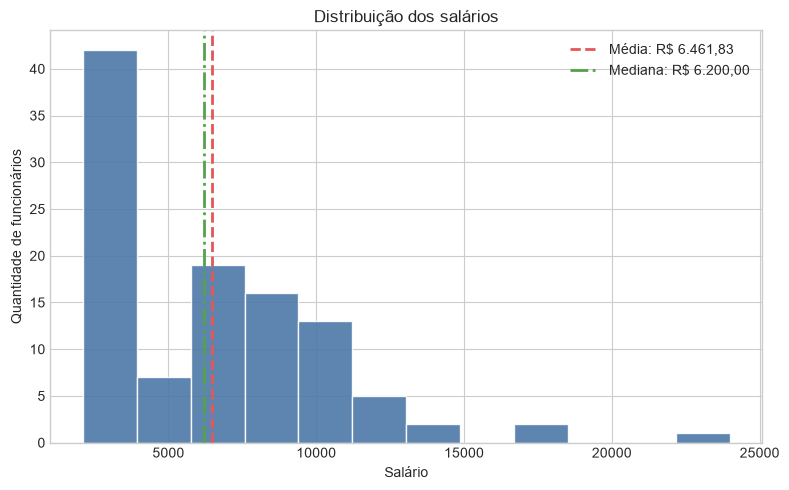

In [12]:
plt.figure(figsize=(8,5))
mean_salary = df1["SALARY"].mean()
median_salary = df1["SALARY"].median()
ax = plt.gca()
ax.hist(df1["SALARY"], bins=12, edgecolor="white", color="#4C78A8", alpha=0.9)
ax.axvline(mean_salary, color="#E45756", linestyle="--", linewidth=2, label=f"Média: {format_currency(mean_salary)}")
ax.axvline(median_salary, color="#54A24B", linestyle="-.", linewidth=2, label=f"Mediana: {format_currency(median_salary)}")
ax.set_title("Distribuição dos salários")
ax.set_xlabel("Salário")
ax.set_ylabel("Quantidade de funcionários")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "histograma_salarios.png", dpi=150, bbox_inches="tight")
if not RUNNING_AS_SCRIPT:
    plt.show()
plt.close()

O histograma mostra que a maior parte dos colaboradores está concentrada nas faixas salariais mais baixas e intermediárias.

A linha da média acima da mediana reforça a presença de salários altos que puxam a distribuição para a direita, embora a maior parte dos valores esteja concentrada abaixo de R$ 10.000,00.

## 5.3 Média salarial por departamento

A seguir é apresentada a média salarial dos colaboradores em cada departamento, permitindo identificar diferenças entre os setores da empresa.


In [13]:
df1.groupby("DEPARTMENT_NAME")["SALARY"].mean().sort_values(ascending=False)

DEPARTMENT_NAME
Executive          19,333.33
Accounting         10,154.00
Public Relations   10,000.00
Marketing           9,500.00
Sales               8,955.88
Finance             8,601.33
Human Resources     6,500.00
IT                  5,760.00
Administration      4,400.00
Purchasing          4,150.00
Shipping            3,475.56
Name: SALARY, dtype: float64

A média salarial por departamento mostra que o setor Executive possui a maior remuneração média (R$ 19.333,33), enquanto o departamento Shipping apresenta a menor média salarial (R$ 3.475,56).

Esse contraste evidencia que a remuneração varia bastante conforme o papel estratégico e a natureza das atividades de cada área.

## 5.4 Top 10 cargos com maior média salarial


In [14]:
media_cargo = (
    df1.groupby("JOB_TITLE")["SALARY"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
media_cargo

JOB_TITLE
President                         24,000.00
Administration Vice President     17,000.00
Marketing Manager                 13,000.00
Sales Manager                     12,200.00
Finance Manager                   12,008.00
Accounting Manager                12,008.00
Purchasing Manager                11,000.00
Public Relations Representative   10,000.00
Sales Representative               8,350.00
Public Accountant                  8,300.00
Name: SALARY, dtype: float64

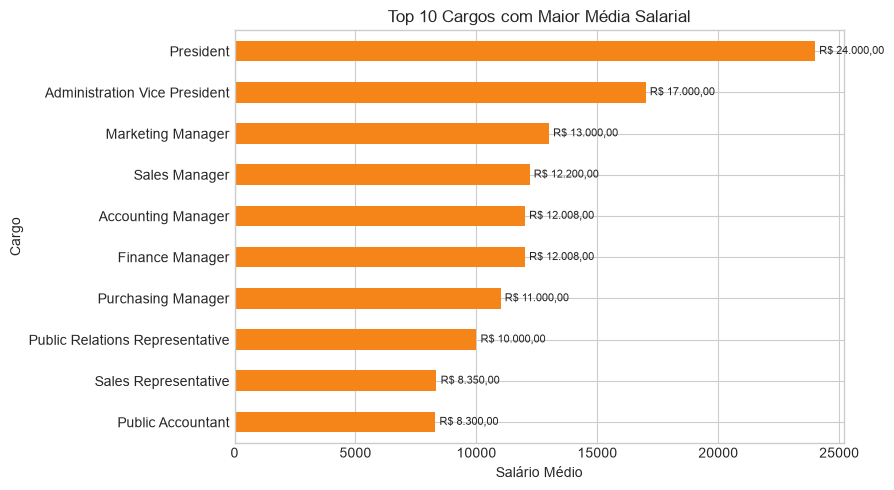

In [15]:
media_cargo_plot = media_cargo.sort_values()
fig, ax = plt.subplots(figsize=(9,5))
media_cargo_plot.plot(kind="barh", ax=ax, color="#F58518")
ax.set_title("Top 10 Cargos com Maior Média Salarial")
ax.set_xlabel("Salário Médio")
ax.set_ylabel("Cargo")
ax.bar_label(ax.containers[0], labels=[format_currency(v) for v in media_cargo_plot], padding=3, fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_10_cargos_maior_media_salarial.png", dpi=150, bbox_inches="tight")
if not RUNNING_AS_SCRIPT:
    plt.show()
plt.close()

A análise por cargo permite identificar quais funções concentram as maiores remunerações médias.

No topo da lista aparecem cargos de liderança e gestão, como President, Administration Vice President, Marketing Manager, Sales Manager e Finance Manager, o que reforça a relação entre responsabilidade e salário.

## 5.5 Boxplot do salário por departamento


<Figure size 1200x600 with 0 Axes>

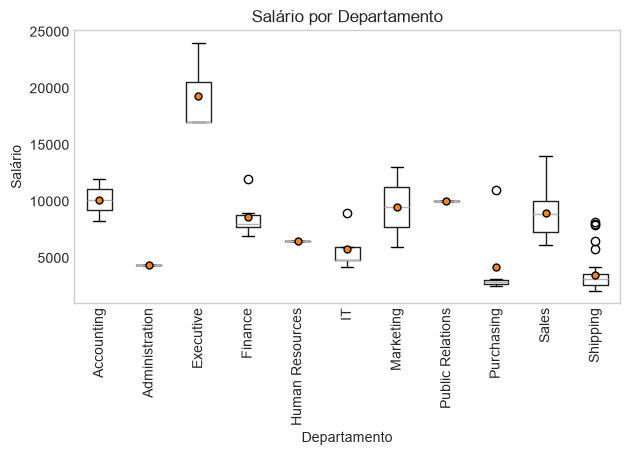

In [16]:
plt.figure(figsize=(12,6))
df1.boxplot(
    column="SALARY",
    by="DEPARTMENT_NAME",
    rot=90,
    grid=False,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "#F58518",
        "markeredgecolor": "black",
        "markersize": 5,
    },
)
plt.title("Salário por Departamento")
plt.suptitle("")
plt.xlabel("Departamento")
plt.ylabel("Salário")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "boxplot_salario_por_departamento.png", dpi=150, bbox_inches="tight")
if not RUNNING_AS_SCRIPT:
    plt.show()
plt.close()

O boxplot permite visualizar a distribuição dos salários em cada departamento, destacando a mediana, a dispersão dos valores e possíveis outliers.

Observa-se que o departamento Executive possui os maiores salários, enquanto Shipping, Purchasing e Administration apresentam remunerações mais baixas.

A presença de pontos mais afastados em alguns setores mostra diferenças salariais internas e ajuda a contextualizar a variabilidade da base.

## 5.6 Salário Médio por Cargo (Horizontal)


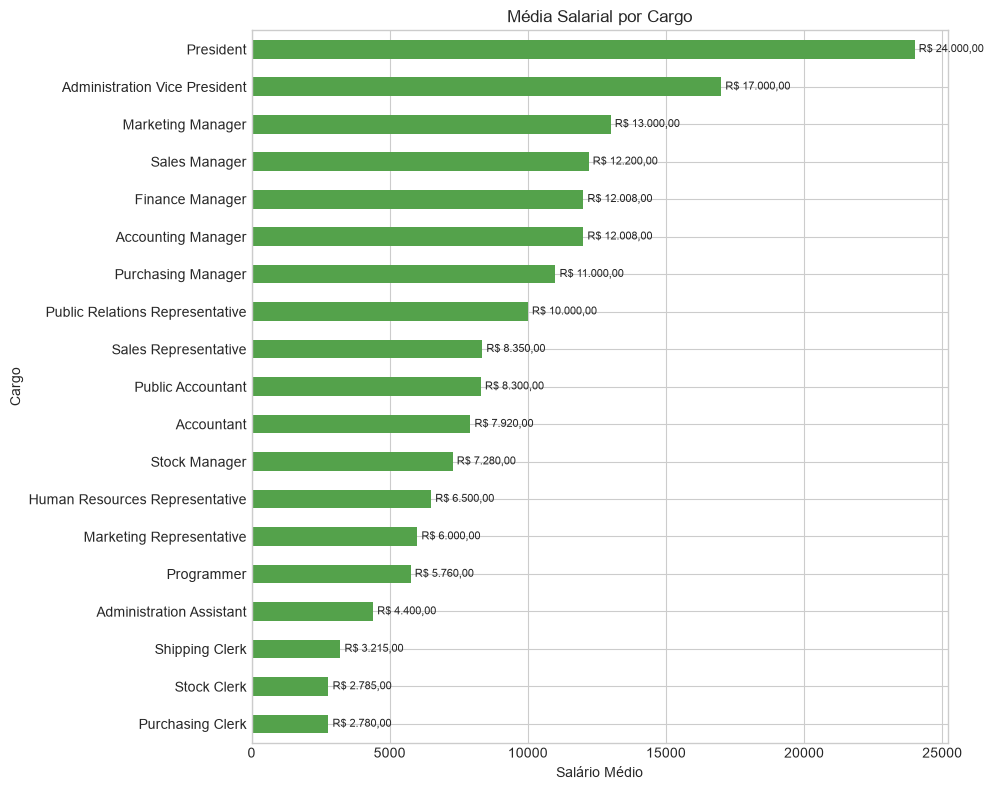

In [17]:
cargo = (
    df1.groupby("JOB_TITLE")["SALARY"]
    .mean()
    .sort_values()
)
fig, ax = plt.subplots(figsize=(10,8))
cargo.plot(kind="barh", ax=ax, color="#54A24B")
ax.set_title("Média Salarial por Cargo")
ax.set_xlabel("Salário Médio")
ax.set_ylabel("Cargo")
ax.bar_label(ax.containers[0], labels=[format_currency(v) for v in cargo], padding=3, fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "media_salarial_por_cargo.png", dpi=150, bbox_inches="tight")
if not RUNNING_AS_SCRIPT:
    plt.show()
plt.close()

# 6.Análise Geográfica


## 6.1 Integração dos Dados


In [18]:
print("Query 1:", df1.shape)
print("Query 2:", df2.shape)


Query 1: (107, 6)
Query 2: (106, 7)


## 6.2 Média salarial por região

Como a região está no df2, vamos juntar os dois DataFrames.


In [19]:
df = pd.merge(
    df1,
    df2[["EMPLOYEE_ID", "REGION_NAME"]],
    on="EMPLOYEE_ID",
    how="left"
)

df_regiao = df.dropna(subset=["REGION_NAME"]).copy()

In [20]:
df.shape

(107, 7)

In [21]:
df1.shape, df2.shape, df.shape, df_regiao.shape

((107, 6), (106, 7), (107, 7), (106, 7))

A junção entre as bases resultou em 107 registros, preservando todos os funcionários da Query 1.

Como a Query 2 possui 106 linhas, um colaborador não apresentou correspondência geográfica. Dessa forma, as análises por região utilizam 106 registros com localização preenchida.

In [22]:
df_regiao.groupby("REGION_NAME")["SALARY"].mean().sort_values()

REGION_NAME
Americas   5,191.66
Europe     8,916.67
Name: SALARY, dtype: float64

Após a junção dos DataFrames, foi calculada a média salarial por região.

Os resultados mostram que a região Europe possui a maior média salarial (R$ 8.916,67), enquanto a região Americas apresenta média de aproximadamente R$ 5.191,66, evidenciando diferenças de remuneração entre as regiões analisadas.

## 6.3 Gráfico da média salarial por região


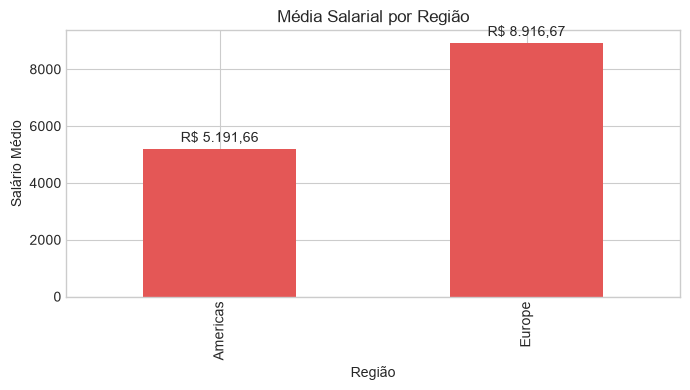

In [23]:
media_regiao = df_regiao.groupby("REGION_NAME")["SALARY"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7,4))
media_regiao.plot(kind="bar", ax=ax, color="#E45756")
ax.set_title("Média Salarial por Região")
ax.set_xlabel("Região")
ax.set_ylabel("Salário Médio")
ax.bar_label(ax.containers[0], labels=[format_currency(v) for v in media_regiao], padding=3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "media_salarial_por_regiao.png", dpi=150, bbox_inches="tight")
if not RUNNING_AS_SCRIPT:
    plt.show()
plt.close()

Observa-se que a região Europe apresenta a maior média salarial (R$ 8.916,67), enquanto a região Americas possui média de aproximadamente R$ 5.191,66, demonstrando diferenças na remuneração média entre as regiões.

## 6.4 Quantidade de Funcionários por Região


Como complemento, esta etapa mostra quantos funcionários possuem informação geográfica válida em cada região. Isso ajuda a contextualizar a média salarial regional e a entender o peso de cada grupo na análise.


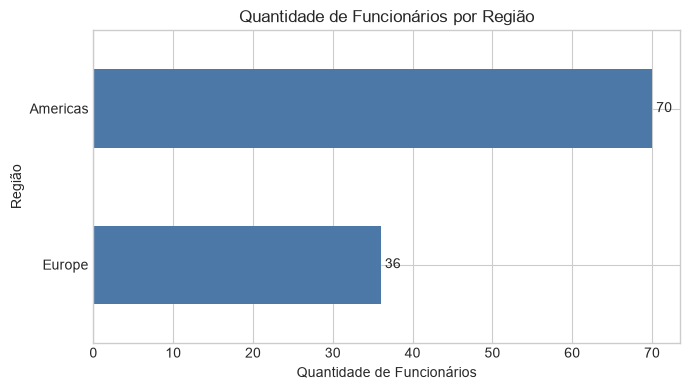

In [24]:
func_por_regiao = df_regiao["REGION_NAME"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(7,4))
func_por_regiao.plot(kind="barh", ax=ax, color="#4C78A8")
ax.set_title("Quantidade de Funcionários por Região")
ax.set_xlabel("Quantidade de Funcionários")
ax.set_ylabel("Região")
ax.bar_label(ax.containers[0], labels=[str(int(v)) for v in func_por_regiao], padding=3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "quantidade_funcionarios_por_regiao.png", dpi=150, bbox_inches="tight")
if not RUNNING_AS_SCRIPT:
    plt.show()
plt.close()


# 7.Análises Adicionais


func_por_depto = df1["DEPARTMENT_NAME"].value_counts().sort_values()
func_por_depto

fig, ax = plt.subplots(figsize=(8,5))
func_por_depto.plot(kind="barh", ax=ax, color="#72B7B2")
ax.set_title("Quantidade de Funcionários por Departamento")
ax.set_xlabel("Quantidade de Funcionários")
ax.set_ylabel("Departamento")
ax.bar_label(ax.containers[0], labels=[str(int(v)) for v in func_por_depto], padding=3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "quantidade_funcionarios_por_departamento.png", dpi=150, bbox_inches="tight")
if not RUNNING_AS_SCRIPT:
    plt.show()
plt.close()

In [25]:
func_por_depto = df1["DEPARTMENT_NAME"].value_counts()
func_por_depto

DEPARTMENT_NAME
Shipping            45
Sales               34
Finance              6
Purchasing           6
IT                   5
Executive            3
Marketing            2
Accounting           2
Public Relations     1
Human Resources      1
Administration       1
Name: count, dtype: int64

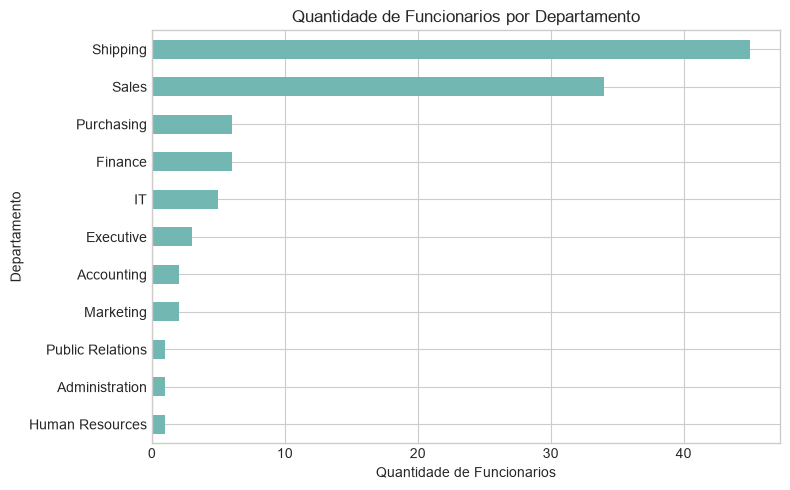

In [26]:
func_por_depto.sort_values().plot(kind="barh", figsize=(8,5), color="#72B7B2")
plt.title("Quantidade de Funcionarios por Departamento")
plt.xlabel("Quantidade de Funcionarios")
plt.ylabel("Departamento")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "quantidade_funcionarios_por_departamento.png", dpi=150, bbox_inches="tight")
if not RUNNING_AS_SCRIPT:
    plt.show()
plt.close()


resumo_departamento = df1.groupby("DEPARTMENT_NAME").agg(
    MEDIA_SALARIAL=("SALARY", "mean"),
    QTD_FUNCIONARIOS=("EMPLOYEE_ID", "count")
).sort_values("MEDIA_SALARIAL", ascending=False).round(2)
resumo_departamento

## 7.2 Média salarial x quantidade de funcionários por departamento


In [27]:
resumo_departamento = df1.groupby("DEPARTMENT_NAME").agg(
    MEDIA_SALARIAL=("SALARY", "mean"),
    QTD_FUNCIONARIOS=("EMPLOYEE_ID", "count")
).sort_values("MEDIA_SALARIAL", ascending=False)
resumo_departamento

,MEDIA_SALARIAL,QTD_FUNCIONARIOS
DEPARTMENT_NAME,,
Executive,"19,333.33",3
Accounting,"10,154.00",2
Public Relations,"10,000.00",1
Marketing,"9,500.00",2
Sales,"8,955.88",34
Finance,"8,601.33",6
Human Resources,"6,500.00",1
IT,"5,760.00",5
Administration,"4,400.00",1


faixas = pd.cut(
    df1["SALARY"],
    bins=[0,4000,7000,10000,25000],
    labels=[
        "Até R$ 4.000",
        "R$ 4.001 - 7.000",
        "R$ 7.001 - 10.000",
        "Acima de R$ 10.000"
    ]
)
faixas_contagem = faixas.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8,4))
faixas_contagem.plot(kind="bar", ax=ax, color="#B279A2")
ax.set_title("Distribuição dos Funcionários por Faixa Salarial")
ax.set_xlabel("Faixa Salarial")
ax.set_ylabel("Quantidade")
ax.bar_label(ax.containers[0], labels=[str(int(v)) for v in faixas_contagem], padding=3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "distribuicao_por_faixa_salarial.png", dpi=150, bbox_inches="tight")
if not RUNNING_AS_SCRIPT:
    plt.show()
plt.close()

## 7.3 Faixas Salariais


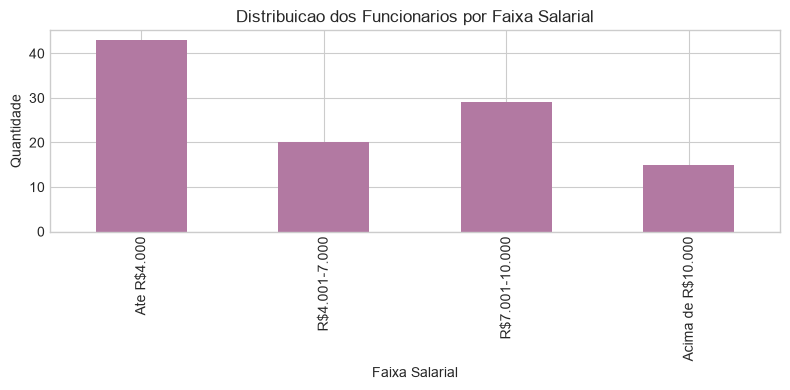

In [28]:
faixas = pd.cut(
    df1["SALARY"],
    bins=[0,4000,7000,10000,25000],
    labels=[
        "Ate R$4.000",
        "R$4.001-7.000",
        "R$7.001-10.000",
        "Acima de R$10.000"
    ]
)
faixas.value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,4),
    color="#B279A2"
)
plt.title("Distribuicao dos Funcionarios por Faixa Salarial")
plt.xlabel("Faixa Salarial")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "distribuicao_por_faixa_salarial.png", dpi=150, bbox_inches="tight")
if not RUNNING_AS_SCRIPT:
    plt.show()
plt.close()


Q1 = df1["SALARY"].quantile(0.25)
Q3 = df1["SALARY"].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
outliers = df1[
    (df1["SALARY"] < limite_inferior) |
    (df1["SALARY"] > limite_superior)
]

print(f"Q1: {format_currency(Q1)}")
print(f"Q3: {format_currency(Q3)}")
print(f"IQR: {format_currency(IQR)}")
print(f"Limite inferior: {format_currency(limite_inferior)}")
print(f"Limite superior: {format_currency(limite_superior)}")
outliers

# 8.Identificação de Outliers

Esta etapa identifica quais funcionários possuem salários considerados fora do padrão estatístico através do método do Intervalo Interquartil (IQR).



In [29]:
Q1 = df1["SALARY"].quantile(0.25)
Q3 = df1["SALARY"].quantile(0.75)
IQR = Q3 - Q1
outliers = df1[
    (df1["SALARY"] < Q1 - 1.5 * IQR) |
    (df1["SALARY"] > Q3 + 1.5 * IQR)
]
outliers

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,SALARY,JOB_TITLE,DEPARTMENT_NAME
0,100,Steven,King,24000,President,Executive


Foi identificado 1 funcionário com salário acima do padrão estatístico do conjunto de dados, pertencente ao departamento Executive e ao cargo President.

Esse valor é o único acima do limite superior calculado pelo método IQR, reforçando seu caráter de outlier.

# 9.Principais Insights


- O departamento Executive possui a maior remuneração média da empresa, indicando concentração de cargos estratégicos.


- Shipping é o departamento com menor média salarial e também um dos que possuem maior número de colaboradores.

- A Europa apresentou média salarial superior à região Americas para os funcionários presentes na base analisada.

- Apenas um salário foi considerado outlier, indicando que a distribuição salarial é relativamente consistente.


# 10.Limitações da Análise


A análise foi realizada com base em duas consultas SQL extraídas do banco de dados HR. Algumas informações presentes na base original não foram utilizadas, pois não faziam parte do escopo do projeto.

Além disso, um funcionário da base salarial não possuía correspondência na base geográfica, motivo pelo qual a análise por região considerou 106 registros com localização preenchida.

# 11.Conclusão



A análise permitiu compreender a estrutura salarial dos colaboradores a partir de duas perspectivas principais: departamentos e regiões.

Os resultados mostraram que o departamento Executive concentra as maiores remunerações, enquanto Shipping apresenta a menor média salarial.

Também foi observado que a região Europe possui média salarial superior à região Americas, considerando os registros com informações geográficas disponíveis.

A EDA também revelou que a maior parte dos salários está concentrada em faixas mais baixas e intermediárias, enquanto poucos colaboradores possuem remunerações muito elevadas. Esse comportamento foi confirmado pela identificação de um outlier, pertencente ao departamento Executive, indicando um salário significativamente acima do padrão geral.

As queries foram essenciais para organizar os dados em duas bases complementares: uma voltada à análise salarial e outra à análise geográfica. A junção dessas bases permitiu ampliar a análise e gerar insights mais completos sobre a distribuição de salários na empresa.

Para análises futuras, seria interessante avaliar salários por cargo, comparar remuneração entre países e cidades, verificar a proporção de funcionários por departamento e criar faixas salariais para apoiar decisões relacionadas à contratação de novos colaboradores.

# 12.Apêndice A – Consultas SQL Utilizadas


As consultas SQL nos campos abaixo foram utilizadas para extrair os dados do banco HR, posteriormente exportados em formato CSV para a realização da Análise Exploratória de Dados (EDA).

Encontram-se disponibilizados no repositório os arquivos `sql/consultas_sql.sql`, `data/query_01.csv`, `data/query_02.csv` e `src/analise_eda.py`, que compõem o material principal deste projeto.

In [30]:
"""
# QUERY 1: Funcionários, cargos e departamentos
SELECT
    e.employee_id,
    e.first_name,
    e.last_name,
    e.salary,
    j.job_title,
    d.department_name
FROM hr.employees e
LEFT JOIN hr.jobs j
    ON e.job_id = j.job_id
LEFT JOIN hr.departments d
    ON e.department_id = d.department_id
WHERE e.salary IS NOT NULL
ORDER BY e.salary DESC;
"""


'\n# QUERY 1: Funcionários, cargos e departamentos\nSELECT\n    e.employee_id,\n    e.first_name,\n    e.last_name,\n    e.salary,\n    j.job_title,\n    d.department_name\nFROM hr.employees e\nLEFT JOIN hr.jobs j\n    ON e.job_id = j.job_id\nLEFT JOIN hr.departments d\n    ON e.department_id = d.department_id\nWHERE e.salary IS NOT NULL\nORDER BY e.salary DESC;\n'

In [31]:
"""
# QUERY 2: Funcionários, departamentos e localização
SELECT
    e.employee_id,
    e.first_name,
    e.last_name,
    d.department_name,
    l.city,
    c.country_name,
    r.region_name
FROM hr.employees e
LEFT JOIN hr.departments d
    ON e.department_id = d.department_id
LEFT JOIN hr.locations l
    ON d.location_id = l.location_id
LEFT JOIN hr.countries c
    ON l.country_id = c.country_id
LEFT JOIN hr.regions r
    ON c.region_id = r.region_id
WHERE d.department_name IS NOT NULL
ORDER BY r.region_name, c.country_name, l.city;
"""


'\n# QUERY 2: Funcionários, departamentos e localização\nSELECT\n    e.employee_id,\n    e.first_name,\n    e.last_name,\n    d.department_name,\n    l.city,\n    c.country_name,\n    r.region_name\nFROM hr.employees e\nLEFT JOIN hr.departments d\n    ON e.department_id = d.department_id\nLEFT JOIN hr.locations l\n    ON d.location_id = l.location_id\nLEFT JOIN hr.countries c\n    ON l.country_id = c.country_id\nLEFT JOIN hr.regions r\n    ON c.region_id = r.region_id\nWHERE d.department_name IS NOT NULL\nORDER BY r.region_name, c.country_name, l.city;\n'